# Debugging Exercises, Solutions

This notebook contains my solutions to the programming debugging exercises for the Master Computer Vision & Data Science admission procedure.

I have kept the explanations concise and focused on the actual bugs, the fix, and the reasoning behind each change.


In [1]:
import csv
from pathlib import Path
from typing import Sequence

import numpy as np
import matplotlib.pyplot as plt


## Exercise 1, `id_to_fruit`

### Bug

The original function receives a `set`. A set is unordered, so using an index on a set is not deterministic. The result can change depending on the Python process and is therefore not reliable.

### Fix

Use an ordered collection, such as a list or tuple, and check that the index is inside the valid range.


In [2]:
def id_to_fruit(fruit_id: int, fruits: Sequence[str]) -> str:
    """Return the fruit at a deterministic index from an ordered sequence."""
    if not isinstance(fruit_id, int):
        raise TypeError("fruit_id must be an integer.")

    if fruit_id < 0 or fruit_id >= len(fruits):
        raise IndexError(f"Fruit id {fruit_id} is outside the valid range.")

    return fruits[fruit_id]


fruits = ["apple", "orange", "melon", "kiwi", "strawberry"]

name1 = id_to_fruit(1, fruits)
name3 = id_to_fruit(3, fruits)
name4 = id_to_fruit(4, fruits)

print(name1, name3, name4)
assert (name1, name3, name4) == ("orange", "kiwi", "strawberry")


orange kiwi strawberry


## Exercise 2, `swap`

### Bugs

1. The obvious error is that `coords[:, 0]` was replaced by `coords[:, 1]` instead of swapping `x1` with `y1`.
2. A second issue is in-place assignment with NumPy views. Without copying, assignments can affect later values during the swap.

### Fix

Create a copy and swap the four coordinate columns using explicit column order.


In [3]:
def swap(coords: np.ndarray) -> np.ndarray:
    """Return a copy of the coordinates with x and y coordinates swapped.

    Input format:
    [x1, y1, x2, y2, class_id]

    Output format:
    [y1, x1, y2, x2, class_id]
    """
    if coords.ndim != 2 or coords.shape[1] != 5:
        raise ValueError("coords must have shape [n, 5].")

    swapped = coords.copy()
    swapped[:, [0, 1, 2, 3]] = coords[:, [1, 0, 3, 2]]
    return swapped


coords = np.array([
    [10, 5, 15, 6, 0],
    [11, 3, 13, 6, 0],
    [5, 3, 13, 6, 1],
    [4, 4, 13, 6, 1],
    [6, 5, 13, 16, 1],
])

swapped_coords = swap(coords)
print(swapped_coords)
expected = np.array([
    [5, 10, 6, 15, 0],
    [3, 11, 6, 13, 0],
    [3, 5, 6, 13, 1],
    [4, 4, 6, 13, 1],
    [5, 6, 16, 13, 1],
])
assert np.array_equal(swapped_coords, expected)


[[ 5 10  6 15  0]
 [ 3 11  6 13  0]
 [ 3  5  6 13  1]
 [ 4  4  6 13  1]
 [ 5  6 16 13  1]]


## Exercise 3, `plot_data`

### Bugs

1. Values read from the CSV file are strings. They need to be converted to floats.
2. The assignment describes precision on the x-axis and recall on the y-axis, so the plotted columns and labels should match that description.

### Fix

Convert rows to `float` and plot `precision` as x and `recall` as y.


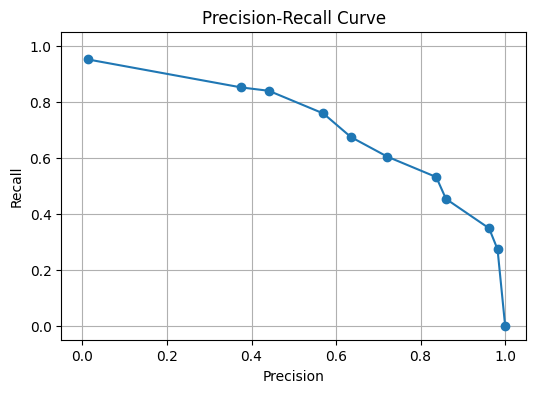

[[0.013 0.951]
 [0.376 0.851]
 [0.441 0.839]]


In [4]:
def plot_data(csv_file_path: str) -> np.ndarray:
    """Plot precision on the x-axis and recall on the y-axis from a CSV file."""
    results = []

    with open(csv_file_path, newline="") as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=",")
        header = next(csv_reader)

        if header != ["precision", "recall"]:
            raise ValueError("CSV header must be: precision, recall")

        for row in csv_reader:
            results.append([float(row[0]), float(row[1])])

    results = np.array(results, dtype=float)

    plt.figure(figsize=(6, 4))
    plt.plot(results[:, 0], results[:, 1], marker="o")
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel("Precision")
    plt.ylabel("Recall")
    plt.title("Precision-Recall Curve")
    plt.grid(True)
    plt.show()

    return results


csv_path = Path("data_file.csv")
with csv_path.open("w", newline="") as f:
    w = csv.writer(f)
    _ = w.writerow(["precision", "recall"])
    w.writerows([
        [0.013, 0.951],
        [0.376, 0.851],
        [0.441, 0.839],
        [0.570, 0.758],
        [0.635, 0.674],
        [0.721, 0.604],
        [0.837, 0.531],
        [0.860, 0.453],
        [0.962, 0.348],
        [0.982, 0.273],
        [1.0, 0.0],
    ])

results = plot_data(str(csv_path))
print(results[:3])
assert results.shape == (11, 2)
assert np.isclose(results[0, 0], 0.013)
assert np.isclose(results[0, 1], 0.951)


## Exercise 4, GAN training function

### Structural bug

The original code creates label tensors using the fixed `batch_size`. This breaks on the final batch when the dataset size is not divisible by the batch size. For example, with `batch_size=64`, the last MNIST batch can contain fewer than 64 images, while the generated samples and labels are still created for 64.

### Fix

Use the actual current batch size:

```python
current_batch_size = real_samples.size(0)
```

Then create the labels and latent vectors using `current_batch_size`, not the fixed `batch_size`.

### Cosmetic bug

The display title says `"Generate images"`, but it should describe the displayed result as `"Generated images"`.


In [5]:
import torch
import torch.nn as nn

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except Exception as error:
    TORCHVISION_AVAILABLE = False
    print(f"torchvision is not available in this environment: {error}")


In [6]:
class Generator(nn.Module):
    """Generator network for the GAN."""

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output


class Discriminator(nn.Module):
    """Discriminator network for the GAN."""

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output


In [7]:
def make_training_loader(batch_size: int):
    """Create the MNIST DataLoader.

    If torchvision or MNIST is not available in the execution environment, this
    function falls back to a small synthetic tensor dataset so that the debugging
    fix can still be tested. On a local Anaconda setup with torchvision, MNIST is
    used as intended by the exercise.
    """
    if TORCHVISION_AVAILABLE:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

        try:
            train_set = torchvision.datasets.MNIST(
                root=".",
                train=True,
                download=True,
                transform=transform,
            )
            return torch.utils.data.DataLoader(
                train_set,
                batch_size=batch_size,
                shuffle=True,
            )
        except Exception as error:
            print(f"MNIST could not be loaded, using synthetic data instead: {error}")

    synthetic_images = torch.randn(130, 1, 28, 28)
    synthetic_labels = torch.zeros(130, dtype=torch.long)
    synthetic_dataset = torch.utils.data.TensorDataset(synthetic_images, synthetic_labels)
    return torch.utils.data.DataLoader(
        synthetic_dataset,
        batch_size=batch_size,
        shuffle=True,
    )


def train_gan(
    batch_size: int = 32,
    num_epochs: int = 1,
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu",
    max_batches: int | None = 2,
):
    """Train a small GAN and fix the final-batch label-size bug."""
    train_loader = make_training_loader(batch_size)

    discriminator = Discriminator().to(device)
    generator = Generator().to(device)

    lr = 0.0001
    loss_function = nn.BCELoss()
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

    for epoch in range(num_epochs):
        for n, (real_samples, _) in enumerate(train_loader):
            real_samples = real_samples.to(device=device)

            # Structural fix: use the actual batch size, not the configured batch_size.
            current_batch_size = real_samples.size(0)

            real_samples_labels = torch.ones((current_batch_size, 1), device=device)
            latent_space_samples = torch.randn((current_batch_size, 100), device=device)
            generated_samples = generator(latent_space_samples)
            generated_samples_labels = torch.zeros((current_batch_size, 1), device=device)

            all_samples = torch.cat((real_samples, generated_samples))
            all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            latent_space_samples = torch.randn((current_batch_size, 100), device=device)

            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
            loss_generator.backward()
            optimizer_generator.step()

            if n == 0:
                title = (
                    f"Generated images, epoch: {epoch}, "
                    f"loss D: {loss_discriminator:.2f}, loss G: {loss_generator:.2f}"
                )
                print(title)

            if max_batches is not None and n + 1 >= max_batches:
                break

    return generator, discriminator


generator, discriminator = train_gan(batch_size=64, num_epochs=1, max_batches=2)
print("GAN dry run completed with batch_size=64.")


Generated images, epoch: 0, loss D: 0.69, loss G: 0.67
GAN dry run completed with batch_size=64.


## Submission note

The final GAN cell uses `batch_size=64` to demonstrate that the structural batch-size bug is fixed.
